# Lakeshore Log Plotter
This notebook can be used to retriece and plot the information contained in a Lakeshore log file. It also loads the frdige logs to compate temperatures as measured directly with the iMACRT system.

The logs need to be locally present on the machine running this notebook. The following commands can be used to retrieve the log files over the NEXUS LAN.

`$ rsync -avu nexusgateway:/mnt/NexusData/Bridge/Temperature_20220419.txt ./`

`$ scp /home/LogData/LakeshoreData/Temperature_20240726.txt nexus-admin@192.168.0.42:/data/SlowDataLogCopies/`

In [1]:
import os
import time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

Define the log file of interest. For now this script only loads one day at a time

In [2]:
date  = "20240728" # "20240727" # "20240726" # 

fname = "Temperature_" + date + ".txt"
fpath = "/data/SlowDataLogCopies"#"/home/nexus-admin/Downloads"
path  = os.path.join(fpath,fname)

In [3]:
plot_time_lims_lo = datetime.datetime(int(date[0:4]),int(date[4:6]),int(date[6:8]),0,0,0)
plot_time_lims_hi = datetime.datetime.now() # datetime.datetime(int(date[0:4]),int(date[4:6]),int(date[6:8]),23,59,59) #  

## Define Utility Methods

### String to timestamp converter
Takes a date/time string in the log file format and returns a unix timestamp. This is used to add a column to the dataframe containing the log file info.

In [4]:
def timeConvert(tstr):
    return time.mktime(datetime.datetime.strptime(tstr.strip(), "%Y-%m-%d %H:%M:%S.%f").timetuple())

### Lakeshore log file parser
Given a path to a local copy of the Lakeshore log file, this method constructs and returns a dataframe containing all the information in the log.

In [5]:
def parse_lakeshore_log_to_df(lakeshore_log_path, verbose=False):
    ## Extract the header column names
    col_names = None
    with open(lakeshore_log_path,"r") as f:
        col_names = f.readline().split()
    if verbose: print(col_names)

    ## Create an empty dataframe with column names
    df = pd.DataFrame(columns=col_names)

    with open(lakeshore_log_path,"r") as f:
        ## Get all the lines in the files
        lines = f.readlines()

        ## Count the number of lines in the file 
        nline = len(lines)

        ## Loop over all rows in file, skipping the first
        for i in 1+np.arange(nline-1):

            ## Parse the line
            line = None
            line = np.array(lines[i].split("\t"))
            l1t  = np.append(line[0:4] , line[4].split())
            line = np.append( l1t, line[5:])
            line[3] = line[3].replace("K","")

            ## Make sure the line has the right number of entries
            if len(line) != len(col_names):
                line = np.append(line, np.empty((len(col_names)-len(line),1), dtype=str))

            ## Add row to end of DataFrame
            df.loc[len(df.index)] = line

    ## Add a converted timestamp column to the dataframe
    df["Tstamp"] = df["Time"].apply(timeConvert)
    
    return df

### Channel data plotter
For a provided log file dataframe object, produce a plot object for a specified channel. If a pyplot `fig` object is passed with the keywork argument `fig_obj` this method adds the requested channel's data to the existing figure. If not, it creates and returns a new figure.

In [6]:
def plotChannel(log_df, chan, fig_obj=None, label=None, **kwargs):
    
    ## Ensure we're looking at strings only
    if not (type(chan)==type("s")):
        chan = str(chan)
        
    ## Get the dataframe entries for this channel
    chan_df = df[ df["Channel"] == chan ]
    
    ## Get the data to plot
    t_vals = chan_df["Tstamp"].to_numpy().astype(type(1.1))      ## Epoch seconds
    T_vals = chan_df["Temperature"].to_numpy()                   ## Kelvin
    
    ## Clean and recast the data of interest
    T_vals[ T_vals == 'Out of Range' ] = np.nan
    T_vals[ T_vals == 'N/A' ] = np.nan
    T_vals    = 1000.0 * T_vals.astype(type(1.1))                ## milliKelvin
    t_vals_dt = np.vectorize(datetime.datetime.fromtimestamp)(t_vals-5*3600)
    
    ## Create the plot
    if fig_obj is None:
        fig = plt.figure()
    ax0 = fig_obj.gca()
    ax0.set_xlabel("Time")
    ax0.set_ylabel("Temperature [mK]")
    
    ## Draw the line
    ax0.plot(t_vals_dt,T_vals,label=label, **kwargs)
    
    ## Change the time format
    ax0.xaxis.set_major_formatter( DateFormatter('%H:%M:%S') )
    for tick in ax0.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('right')
        tick.set_rotation(30)

    return fig_obj, ax0, t_vals_dt, T_vals,

## Load the Data
Now actually load the data from the specified date into a dataframe

In [7]:
df = parse_lakeshore_log_to_df(path)
## Show the user the data
df

,Channel,Measurement,Resistance,Temperature,Res,Range,Excitation,Time,ControlSetup,ControlChannel,CurveName,HeaterRange,PID_P,PID_I,PID_D,SetupUnit,SetPoint,HeatResistance,HeaterPower,Tstamp
0,11,SQUID Board Therm Soudan#11,2035.37 Ohms,1.030783,6.32,kOhms,20.0 uV,2024-07-28 05:00:05.165\n,,,,,,,,,,,,1.722161e+09
1,13,PT Fridge Touch Sensor Resistor(50 kOhm),50797.1 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-28 05:00:13.832\n,,,,,,,,,,,,1.722161e+09
2,4,RF Payload Therm TT2101,10728.9 Ohms,0.099965,20.0,kOhms,6.32 uV,2024-07-28 05:00:22.665\n,,,,,,,,,,,,1.722161e+09
3,5,DC Tower Therm Soudan#12,2301.44 Ohms,0.117848,6.32,kOhms,6.32 uV,2024-07-28 05:00:31.395\n,,,,,,,,,,,,1.722161e+09
4,11,SQUID Board Therm Soudan#11,2031.07 Ohms,1.035054,6.32,kOhms,20.0 uV,2024-07-28 05:00:40.136\n,,,,,,,,,,,,1.722161e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5852,4,RF Payload Therm TT2101,10275.1 Ohms,0.106809,20.0,kOhms,6.32 uV,2024-07-28 21:38:27.145\n,,,,,,,,,,,,1.722221e+09
5853,5,DC Tower Therm Soudan#12,2286.85 Ohms,0.121780,6.32,kOhms,6.32 uV,2024-07-28 21:38:35.853\n,,,,,,,,,,,,1.722221e+09
5854,11,SQUID Board Therm Soudan#11,2075.59 Ohms,0.171315,6.32,kOhms,20.0 uV,2024-07-28 21:38:44.524\n,,,,,,,,,,,,1.722221e+09
5855,13,PT Fridge Touch Sensor Resistor(50 kOhm),50952.9 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-28 21:38:53.183\n,,,,,,,,,,,,1.722221e+09


In [8]:
## Show the user the unique channels that are logged in this file
chans = set(df["Channel"])
print("Channels available in this log file:", chans)

Channels available in this log file: {'4', '11', '13', '5'}


(19932.0, 19932.69426753853)

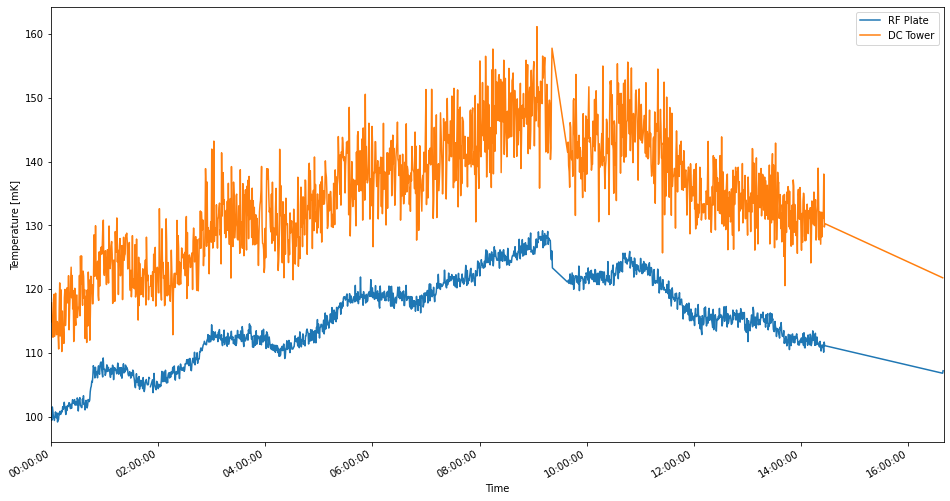

In [9]:
# %matplotlib notebook
fig = plt.figure(figsize=(16,8))
_, _, rf_times, rf_temps = plotChannel(df, 4,fig_obj=fig,label="RF Plate")
_, _, dc_times, dc_temps = plotChannel(df, 5,fig_obj=fig,label="DC Tower")
plt.legend()

xlim = plt.gca().get_xlim()
fig.gca().set_xlim([plot_time_lims_lo , plot_time_lims_hi])

In [10]:
rf_times64 = np.array([ np.datetime64(dt) for dt in rf_times ])
dc_times64 = np.array([ np.datetime64(dt) for dt in dc_times ])

## Load the iMACRT Temperatures

In [11]:
import sys
sys.path.append('../')
import NEXUSFunctions as nf

import matplotlib.dates as mdates
from   pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [12]:
seriesstr = "-".join([date[0:4],date[4:6],date[6:8]])
series    = nf.create_date_range(seriesstr,1)
offset_0  = datetime.timedelta(days=0, hours=0, minutes=0)
offset_ls = datetime.timedelta(days=0, hours=-5, minutes=0)

The starting date is: 
2024-07-28 00:00:00


In [13]:
res_mc    = nf.read_MACRT_data(series, offset_0)

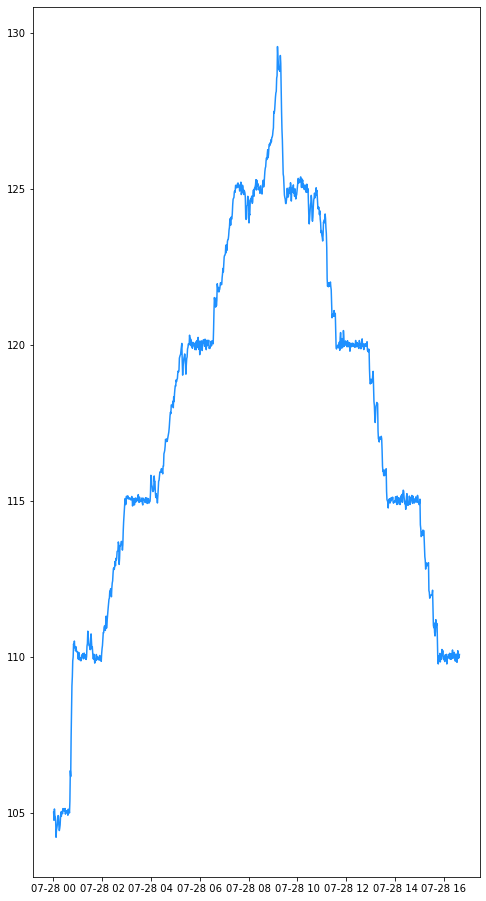

In [14]:
## Plot the MACRT data
plt.figure(figsize=(8,16))
plt.plot(res_mc['ctime'], res_mc['MIXING CHAMB_Conv']*1e3, label='MACRT - MC', color='dodgerblue', zorder=10)

## Load the PLC Temperatures

In [15]:
seriesstr  = "".join([date[2:4],date[4:6],date[6:8]])
series_plc = nf.create_date_range(seriesstr, 1, fmt="%y%m%d")
offset_plc = datetime.timedelta(days=0, hours=0, minutes=0)
data_plc   = nf.read_plclog_data(series_plc, offset_plc)

The starting date is: 
2024-07-28 00:00:00


In [16]:
def get_datetime(obj):
    return obj.to_pydatetime()

data_plc['datetime'] = data_plc['ctime'].apply(get_datetime)
res_mc['datetime'] = res_mc['ctime'].apply(get_datetime)

In [17]:
## Define the setpoint temperatures where we stopped to take data
stop_temps_mK  = np.arange(start=25,stop=130,step=5)
stop_limtol    = 2e-3 ## Fractional tolerance on temperature to define periods of stability
stop_lolims_mK = stop_temps_mK * (1-stop_limtol)
stop_hilims_mK = stop_temps_mK * (1+stop_limtol)

## Create containers to record the info for the PLC/MC during periods of stability
good_times_collector = [None] * len(stop_temps_mK)
good_temps_collector = [None] * len(stop_temps_mK)
good_pwrs_collector  = [None] * len(stop_temps_mK)
good_trim_fac = 0.15 ## Fraction of total size to trim off of each end to define the stable period

## Create containers to record the info for the Lakeshore/RF during periods of stability
rf_times_collector = [None] * len(stop_temps_mK)
rf_temps_collector = [None] * len(stop_temps_mK)
rf_save_fac = 0.5 ## Only save the part of the stable period extending from this fraction to the end

## Create containers for the averaged results of each stability period
rf_time_means = [None] * len(stop_temps_mK)
rf_temp_means = np.zeros(len(stop_temps_mK))
rf_temp_stdvs = np.zeros(len(stop_temps_mK))

In [18]:
## Loop over every temperature setpoint
for i,stop_temp in enumerate(stop_temps_mK):
    
    ## For the PLC data, find the indices of the data during the stable period
    good_mc_idxs = np.array( ((np.array(data_plc['FR MC'])*1e3) >= stop_lolims_mK[i]) 
                           * ((np.array(data_plc['FR MC'])*1e3) <= stop_hilims_mK[i]) )
    
    ## If there is no data in this temperature range, write nans
    if np.sum(good_mc_idxs) < 1:
        rf_time_means[i] = np.nan
        rf_temp_means[i] = np.nan
        rf_temp_stdvs[i] = np.nan
        continue
    
    ## Extract the start and end datetimes for the stable period
    ## This allows for fluctuations outside of stable band to not be removed from data
    good_time_start  = np.array(data_plc['datetime'])[good_mc_idxs][0]
    good_time_finish = np.array(data_plc['datetime'])[good_mc_idxs][-1]
    
    ## Pull the PLC data for this stability period, based on the start/end datetimes
    good_times = np.array(data_plc['datetime'])[(np.array(data_plc['datetime'])>=good_time_start)*(np.array(data_plc['datetime'])<=good_time_finish)]
    good_temps = np.array(data_plc['FR MC']   )[(np.array(data_plc['datetime'])>=good_time_start)*(np.array(data_plc['datetime'])<=good_time_finish)]
    good_pwrs  = np.array(data_plc['MC_power'])[(np.array(data_plc['datetime'])>=good_time_start)*(np.array(data_plc['datetime'])<=good_time_finish)]
    
    ## Determine which indeces to trim of either end
    good_len = len(good_times)
    good_min_idx = int(good_len * good_trim_fac)
    good_max_idx = int(good_len * (1-good_trim_fac))
    
    ## Perform the end trimming for the stability period
    good_times_collector[i] = good_times[good_min_idx:good_max_idx]
    good_temps_collector[i] = good_temps[good_min_idx:good_max_idx]
    good_pwrs_collector[i]  = good_pwrs[good_min_idx:good_max_idx]
    
    ## Extract the RF plate data during this period of stability
    rf_times_good = rf_times64[ (rf_times64 >= good_times[0]) * (rf_times64 <= good_times[-1]) ]
    rf_temps_good = rf_temps[   (rf_times64 >= good_times[0]) * (rf_times64 <= good_times[-1]) ]
    rf_good_len   = len(rf_times_good)
    
    ## Record only the last fraction of the stability period, since this is roughly when the VNA scan 
    ## is taken
    rf_times_collector[i] = rf_times_good[int(rf_good_len*rf_save_fac):]
    rf_temps_collector[i] = rf_temps_good[int(rf_good_len*rf_save_fac):]
    
    ## Data may have been missed at this setpoint, resulting in an empty list
    ## If its not empty, save the data
    if len(rf_times_collector[i]) > 0:
        rf_time_means[i] = rf_times_collector[i][-1]
        rf_temp_means[i] = np.mean(rf_temps_collector[i])
        rf_temp_stdvs[i] = np.std(rf_temps_collector[i])
    ## If it is empty, just write nans
    else:
        rf_time_means[i] = np.nan
        rf_temp_means[i] = np.nan
        rf_temp_stdvs[i] = np.nan

<IPython.core.display.Javascript object>


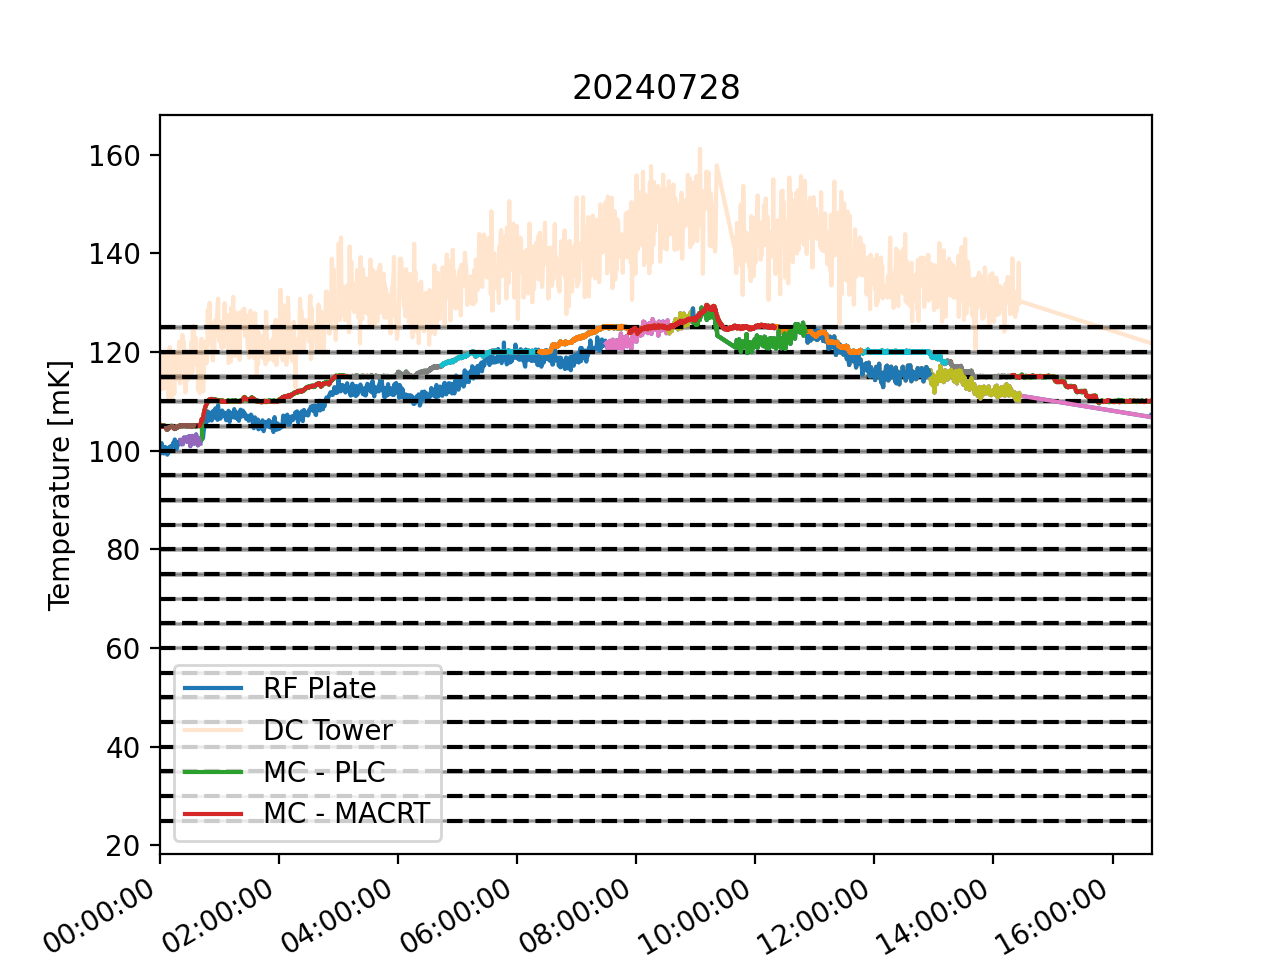

In [19]:
%matplotlib notebook
fig = plt.figure()
ax0 = fig.gca()
ax0.set_title(date)

## Plot the Lakeshore data
plotChannel(df, 4,fig_obj=fig,label="RF Plate")
plotChannel(df, 5,fig_obj=fig,label="DC Tower",alpha=0.2)

## Plot the PLC and iMACRT data
ax0.plot(np.array(data_plc['datetime']), np.array(data_plc['FR MC'])*1e3, label='MC - PLC')
ax0.plot(           res_mc['datetime'] , res_mc['MIXING CHAMB_Conv']*1e3, label='MC - MACRT')

## Zoom in on the times we care about
ax0.set_xlim([plot_time_lims_lo , plot_time_lims_hi])


xlims = ax0.get_xlim()
## Draw the stable periods and guides
for i,stop_temp in enumerate(stop_temps_mK):
    ax0.axhline(y=stop_temp, ls='--', c='k')
    ax0.fill_between(xlims, y1=stop_lolims_mK[i], y2=stop_hilims_mK[i], color='k', alpha=0.3)
    if (rf_times_collector[i] is not None) and (rf_temps_collector[i] is not None):
        ax0.plot(rf_times_collector[i],rf_temps_collector[i])
    if (good_times_collector[i] is not None) and (good_temps_collector[i] is not None):
        ax0.plot( good_times_collector[i], good_temps_collector[i]*1e3)
ax0.set_xlim(xlims)
    
## Draw the digested results
# ax0.errorbar(rf_time_means, rf_temp_means, yerr=5.0*rf_temp_stdvs, marker='o', color='red', ls='None', label=r"$\langle T \rangle ~(\sigma\times5)$")
ax0.legend()


## Look at the Cooling Power
We care about the cooling power results only when the still was at a constant temperature (950 mK). We will want to mask our data to avoid regions where this is not the case.

In [20]:
still_target_mK = 950.0
still_tolerance = 6e-4
still_lolim     = still_target_mK * (1-still_tolerance)
still_hilim     = still_target_mK * (1+still_tolerance)

## Define the mask that corresponds to good still temperature periods
good_still_idxs = np.array( ((np.array(data_plc['Still Stage'])*1e3) >= still_lolim) 
                          * ((np.array(data_plc['Still Stage'])*1e3) <= still_hilim) )

<IPython.core.display.Javascript object>


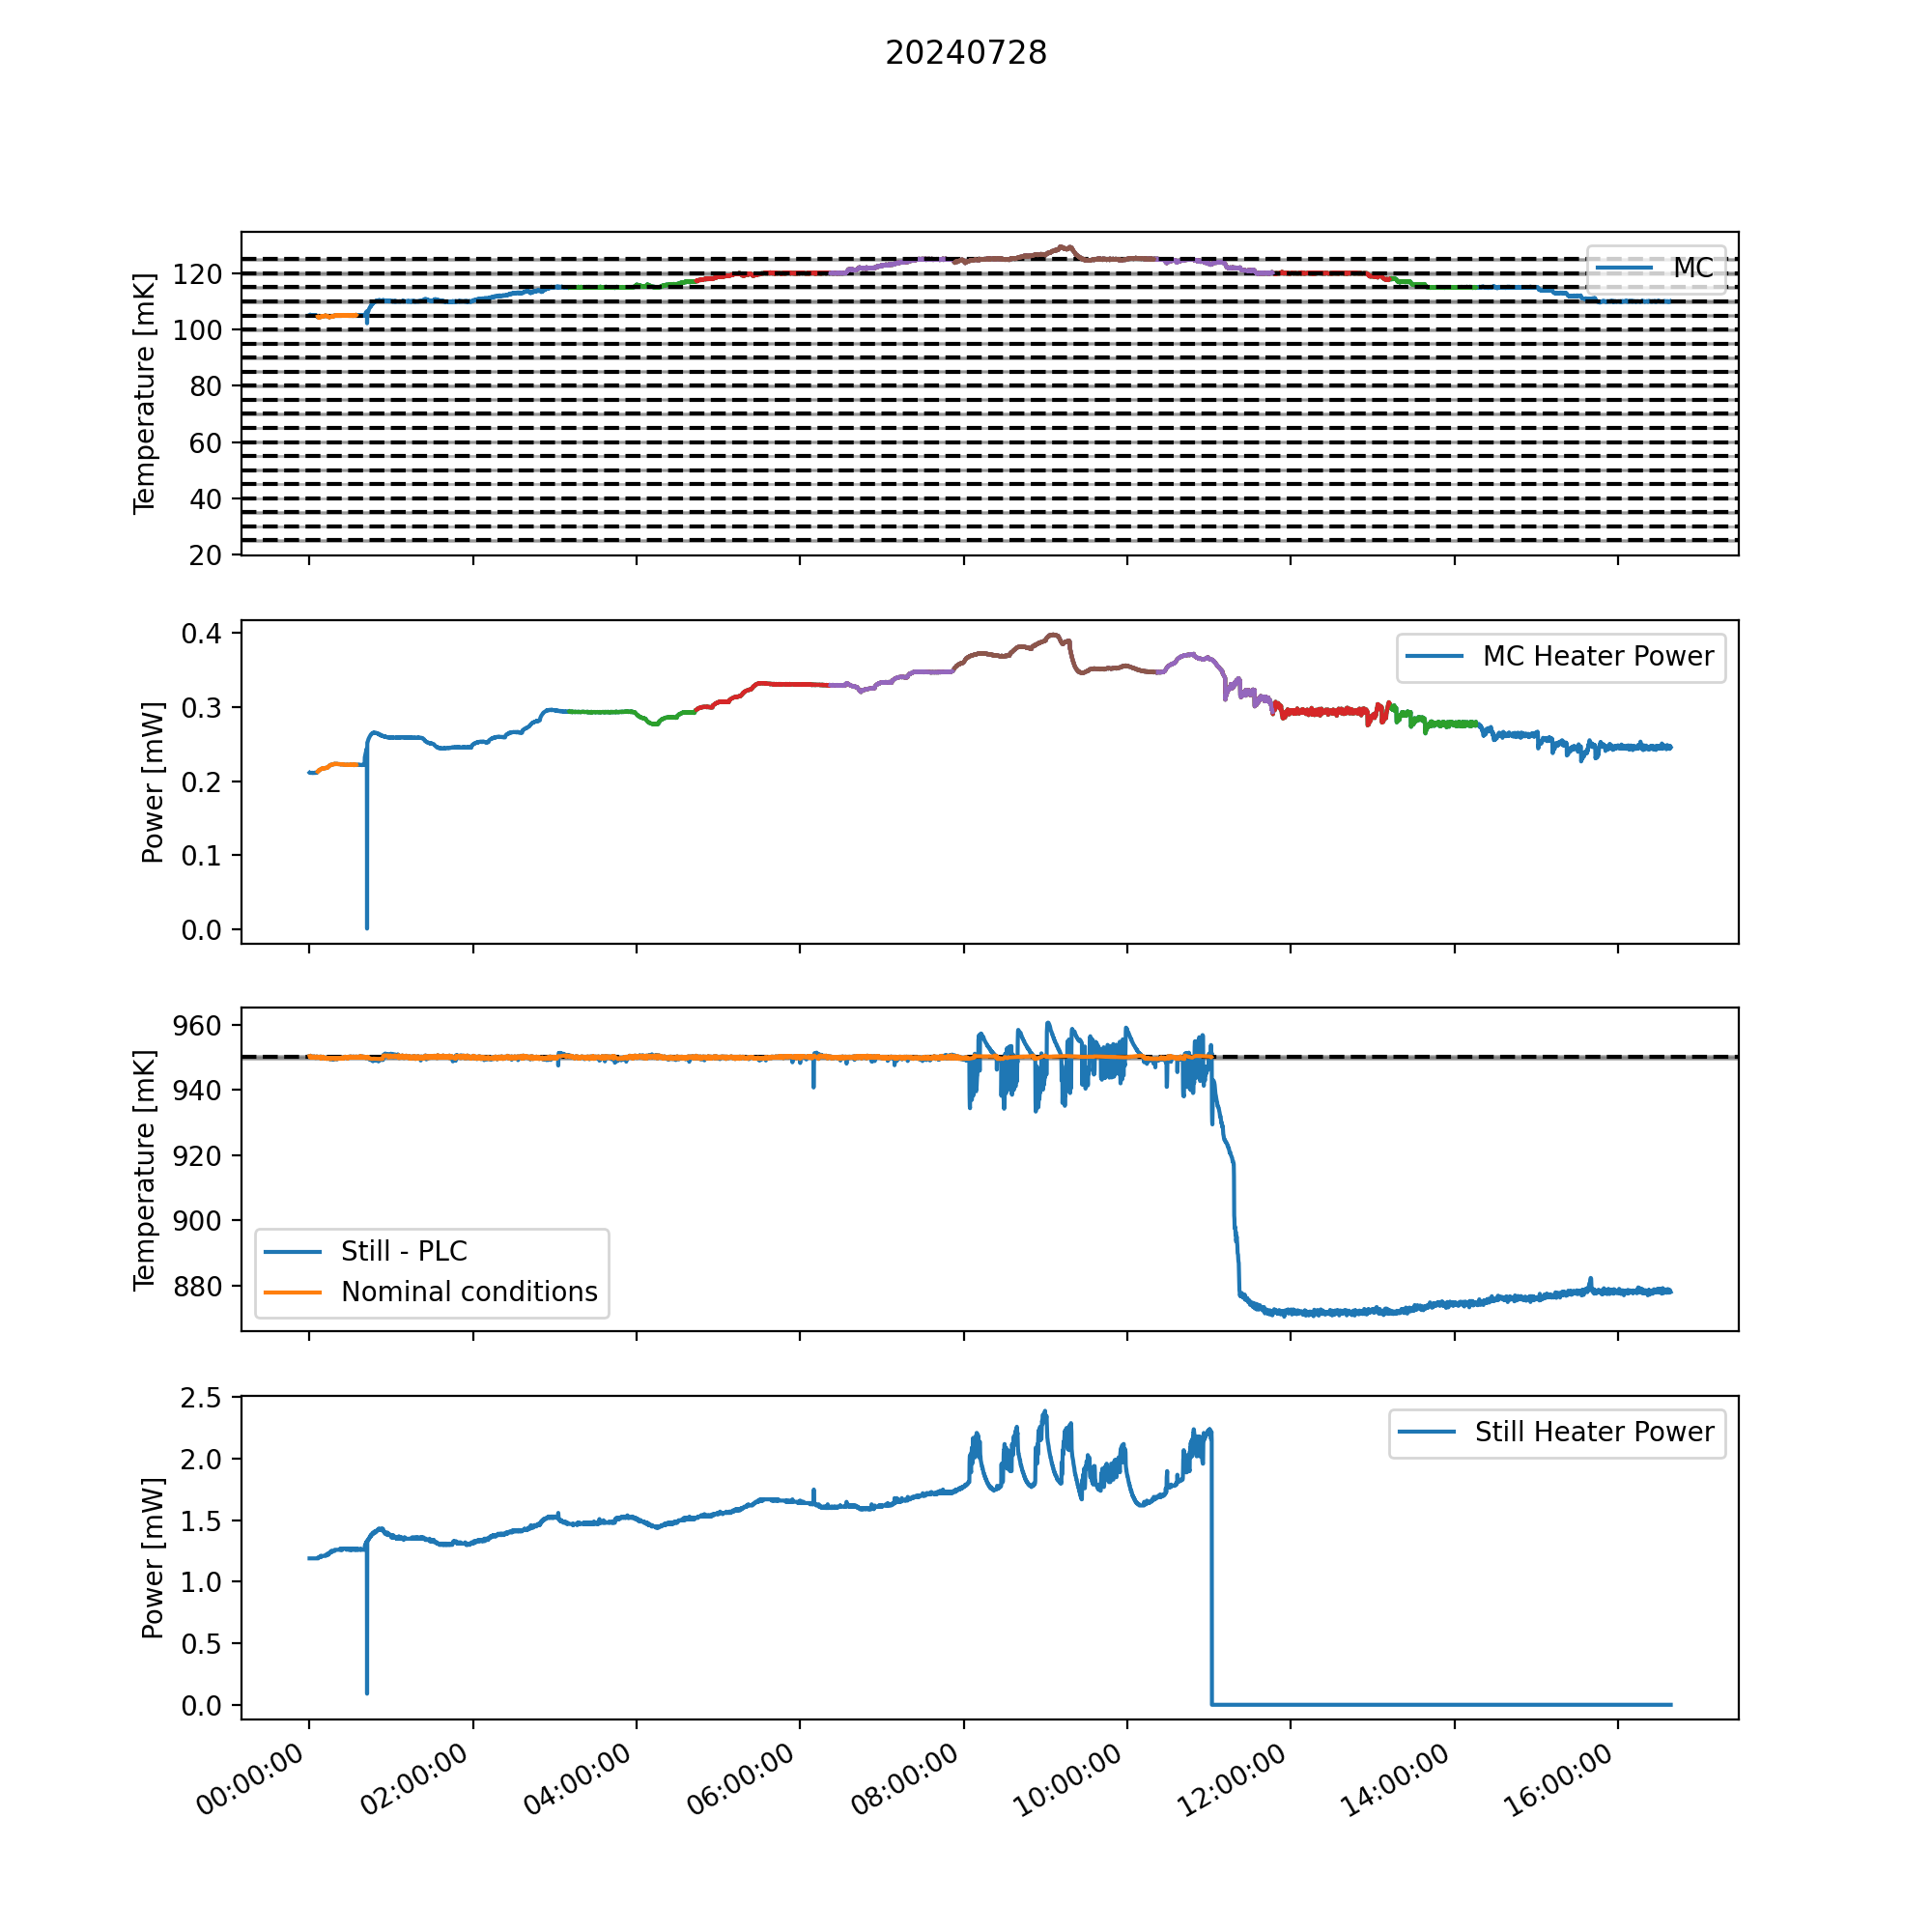

In [21]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10,10), sharex=True)
fig.suptitle(date)

axs[0].plot( np.array(data_plc['datetime']), 
               np.array(data_plc['FR MC'])*1e3, 
               label='MC')
axs[0].set_ylabel("Temperature [mK]")
axs[0].legend()
xlims = axs[0].get_xlim()
for i,stop_temp in enumerate(stop_temps_mK):
    axs[0].axhline(y=stop_temp, ls='--', c='k')
    axs[0].fill_between(xlims, y1=stop_lolims_mK[i], y2=stop_hilims_mK[i], color='k', alpha=0.3)   
    if (good_times_collector[i] is not None) and (good_temps_collector[i] is not None):
        axs[0].plot( good_times_collector[i], 
                     good_temps_collector[i]*1e3)
axs[0].set_xlim(xlims)

axs[1].plot( np.array(data_plc['datetime']), 
               np.array(data_plc['MC_power'])*1e3, 
               label='MC Heater Power')
axs[1].set_ylabel("Power [mW]")
axs[1].legend()
for i,stop_temp in enumerate(stop_temps_mK):
    if (good_times_collector[i] is not None) and (good_pwrs_collector[i] is not None):
        axs[1].plot( good_times_collector[i], 
                     good_pwrs_collector[i]*1e3)
axs[1].set_xlim(xlims)


axs[2].plot( np.array(data_plc['datetime']), 
               np.array(data_plc['Still Stage'])*1e3, 
               label='Still - PLC')
axs[2].set_ylabel("Temperature [mK]")
axs[2].axhline(y=still_target_mK, ls='--', c='k')
xlims = axs[2].get_xlim()
axs[2].fill_between(xlims, y1=still_lolim, y2=still_hilim, color='k', alpha=0.3)
axs[2].plot( np.array(data_plc['datetime'])[good_still_idxs], 
               np.array(data_plc['Still Stage'])[good_still_idxs]*1e3, 
               label='Nominal conditions')
axs[2].set_ylabel("Temperature [mK]")
axs[2].legend()
axs[2].set_xlim(xlims)

axs[3].plot( np.array(data_plc['datetime']), 
               np.array(data_plc['Still_power'])*1e3, 
               label='Still Heater Power')
axs[3].set_ylabel("Power [mW]")
axs[3].legend()
axs[3].set_xlim(xlims)



## Change the time format
for ax0 in axs:
    ax0.xaxis.set_major_formatter( DateFormatter('%H:%M:%S') )
    for tick in ax0.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('right')
        tick.set_rotation(30)



<IPython.core.display.Javascript object>


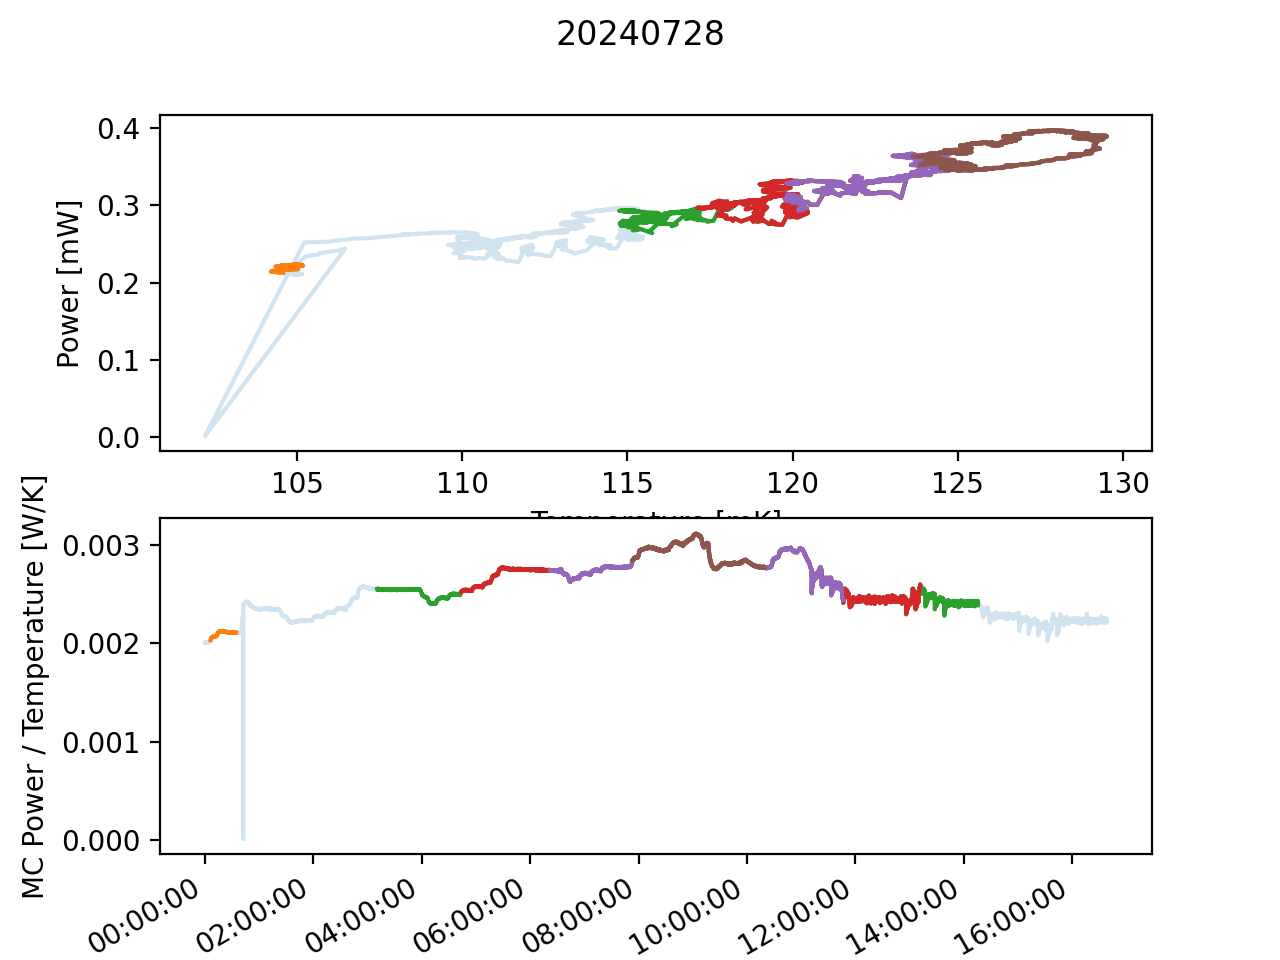

In [22]:
fig, axs = plt.subplots(nrows=2, ncols=1)
fig.suptitle(date)

axs[0].plot( np.array(data_plc['FR MC'])*1e3, 
             np.array(data_plc['MC_power'])*1e3,
             alpha=0.2)
axs[0].set_xlabel("Temperature [mK]")
axs[0].set_ylabel("Power [mW]")
for i,stop_temp in enumerate(stop_temps_mK):
    if (good_temps_collector[i] is not None) and (good_pwrs_collector[i] is not None):
        axs[0].plot( good_temps_collector[i]*1e3, 
                     good_pwrs_collector[i]*1e3)

axs[1].plot( np.array(data_plc['datetime']), 
             np.array(data_plc['MC_power']) / np.array(data_plc['FR MC']), 
             alpha=0.2)
axs[1].set_ylabel("MC Power / Temperature [W/K]")
for i,stop_temp in enumerate(stop_temps_mK):
    if (good_temps_collector[i] is not None) and (good_pwrs_collector[i] is not None):
        axs[1].plot( good_times_collector[i], 
                     good_pwrs_collector[i] / good_temps_collector[i])

## Change the time format
axs[1].xaxis.set_major_formatter( DateFormatter('%H:%M:%S') )
for tick in axs[1].xaxis.get_majorticklabels():
    tick.set_horizontalalignment('right')
    tick.set_rotation(30)

